In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix
import re
from textblob import TextBlob
import joblib
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## Load Data Set

In [5]:
print("Loading data...")
df = pd.read_csv('../data/processed/emails_with_features.csv')

print(f"✅ Loaded {len(df)} emails")
print(f"\nColumns: {list(df.columns)}")
print(f"\nShape: {df.shape}")

# Quick look
df.head(3)

Loading data...
✅ Loaded 1000 emails

Columns: ['email_id', 'subject', 'body', 'priority', 'subject_length', 'body_length', 'word_count', 'exclamations', 'caps_words', 'urgent_words', 'questions']

Shape: (1000, 11)


,email_id,subject,body,priority,subject_length,body_length,word_count,exclamations,caps_words,urgent_words,questions
0,1,Feature not working properly,I am getting an error when I try to export my ...,High,28,77,18,0,0,1,1
1,2,Best practices question,What is the best way to organize my projects i...,Medium,23,59,12,0,0,0,1
2,3,How do I configure this?,What is the best way to organize my projects i...,Medium,24,59,12,0,0,0,1


## CLean and Prepare text

In [6]:
def clean_text(text):
    """
    Clean text for feature extraction.
    
    Note: We keep some "dirty" elements like !!! and CAPS
    because they're actually useful signals for urgency!
    """
    if pd.isna(text):
        return ""
    
    # Convert to string (just in case)
    text = str(text)
    
    # Remove URLs (not useful for priority)
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove email addresses (privacy)
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning
print("Cleaning text...")
df['subject_clean'] = df['subject'].apply(clean_text)
df['body_clean'] = df['body'].apply(clean_text)

# Combine subject and body for full text
df['full_text'] = df['subject_clean'] + ' ' + df['body_clean']

print("✅ Text cleaned!")
print(f"\nExample cleaned text:")
print(df['full_text'].iloc[0])

Cleaning text...
✅ Text cleaned!

Example cleaned text:
Feature not working properly I am getting an error when I try to export my data. Can you help me fix this?


## TF-IDF example

In [7]:
print("-"*70)
print("UNDERSTANDING TF-IDF (Term Frequency - Inverse Document Frequency)")
print("-"*70)

# Simple example
sample_emails = [
    "urgent help needed now",
    "feature request for future",
    "urgent critical issue",
]

print("\n📧 Sample emails:")
for i, email in enumerate(sample_emails, 1):
    print(f"   {i}. {email}")

# Create TF-IDF vectorizer (simple version)
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(sample_emails)

# Show the vocabulary
print(f"\n📚 Vocabulary (unique words found):")
print(f"   {vectorizer.get_feature_names_out()}")

print(f"\n🔢 TF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"   (3 emails × {len(vectorizer.get_feature_names_out())} words)")

# Show matrix as DataFrame for readability
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=['Email 1', 'Email 2', 'Email 3']
)

print(f"\n📊 TF-IDF Values (higher = more important in that email):")
print(tfidf_df)

print("\n💡 KEY INSIGHTS:")
print("   • 'urgent' has HIGH value in emails 1 & 3 (appears there)")
print("   • 'urgent' has ZERO in email 2 (doesn't appear)")
print("   • Words appearing in ALL emails get LOWER scores (less distinctive)")
print("   • Rare words get HIGHER scores (more distinctive)")

----------------------------------------------------------------------
UNDERSTANDING TF-IDF (Term Frequency - Inverse Document Frequency)
----------------------------------------------------------------------

📧 Sample emails:
   1. urgent help needed now
   2. feature request for future
   3. urgent critical issue

📚 Vocabulary (unique words found):
   ['critical' 'feature' 'for' 'future' 'help' 'issue' 'needed' 'now'
 'request' 'urgent']

🔢 TF-IDF Matrix shape: (3, 10)
   (3 emails × 10 words)

📊 TF-IDF Values (higher = more important in that email):
         critical  feature  for  future      help     issue    needed  \
Email 1  0.000000      0.0  0.0     0.0  0.528635  0.000000  0.528635   
Email 2  0.000000      0.5  0.5     0.5  0.000000  0.000000  0.000000   
Email 3  0.622766      0.0  0.0     0.0  0.000000  0.622766  0.000000   

              now  request   urgent  
Email 1  0.528635      0.0  0.40204  
Email 2  0.000000      0.5  0.00000  
Email 3  0.000000      0.0  0.4736

## Extra TF-IDF Features

In [8]:
print("Extracting TF-IDF features...")
print("-"*70)

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=300,        # Keep top 300 most important words
    min_df=2,                # Word must appear in at least 2 emails
    max_df=0.8,              # Ignore words in more than 80% of emails
    ngram_range=(1, 2),      # Use single words AND word pairs
    stop_words='english',    # Remove common words (the, and, is, etc.)
    lowercase=True           # Convert to lowercase for consistency
)

# Fit on training data and transform
tfidf_features = tfidf_vectorizer.fit_transform(df['full_text'])

print(f"✅ TF-IDF features created!")
print(f"\nFeature matrix shape: {tfidf_features.shape}")
print(f"   ({tfidf_features.shape[0]} emails × {tfidf_features.shape[1]} features)")

# Show feature names
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n📚 Sample feature names (words and word pairs):")
print(f"   {list(feature_names[:20])}")

print(f"\n💾 Memory used: {tfidf_features.data.nbytes / 1024:.2f} KB (sparse matrix!)")

Extracting TF-IDF features...
----------------------------------------------------------------------
✅ TF-IDF features created!

Feature matrix shape: (1000, 300)
   (1000 emails × 300 features)

📚 Sample feature names (words and word pairs):
   ['30', '30 minutes', '500', '500 integration', 'access', 'access account', 'access dashboard', 'access files', 'account', 'account hacked', 'account important', 'account locked', 'add', 'add dark', 'adding', 'adding keyboard', 'advanced', 'advanced features', 'advanced filters', 'affecting']

💾 Memory used: 107.25 KB (sparse matrix!)


## Analyze Most Important Words

In [9]:
def get_top_tfidf_words(tfidf_matrix, feature_names, priority_mask, top_n=10):
    """Get words with highest average TF-IDF score for a priority class"""
    
    # Get TF-IDF values for this priority
    priority_tfidf = tfidf_matrix[priority_mask.values]
    
    # Calculate mean TF-IDF score for each word
    mean_tfidf = np.asarray(priority_tfidf.mean(axis=0)).flatten()
    
    # Get top words
    top_indices = mean_tfidf.argsort()[-top_n:][::-1]
    top_words = [(feature_names[i], mean_tfidf[i]) for i in top_indices]
    
    return top_words

print("-"*70)
print("MOST IMPORTANT WORDS BY PRIORITY (TF-IDF Analysis)")
print("-"*70)

for priority in ['Urgent', 'High', 'Medium', 'Low']:
    print(f"\n🔍 {priority.upper()} Priority:")
    print("-"*70)
    
    priority_mask = df['priority'] == priority
    top_words = get_top_tfidf_words(tfidf_features, feature_names, priority_mask, top_n=15)
    
    for word, score in top_words:
        bar = '█' * int(score * 100)
        print(f"   {word:25s} {score:.4f} {bar}")

print("\n" + "-"*70)
print("💡 OBSERVATION:")
print("   • Urgent: 'urgent', 'asap', 'critical', 'locked', 'cannot'")
print("   • Low: 'suggestion', 'feature', 'would', 'nice'")
print("   • Clear vocabulary differences!")
print("-"*70)

----------------------------------------------------------------------
MOST IMPORTANT WORDS BY PRIORITY (TF-IDF Analysis)
----------------------------------------------------------------------

🔍 URGENT Priority:
----------------------------------------------------------------------
   account                   0.1459 ██████████████
   critical                  0.1418 ██████████████
   service                   0.0866 ████████
   access                    0.0841 ████████
   help                      0.0819 ████████
   lost                      0.0779 ███████
   urgent                    0.0777 ███████
   login                     0.0725 ███████
   entire                    0.0658 ██████
   entire service            0.0658 ██████
   team work                 0.0658 ██████
   team                      0.0658 ██████
   service team              0.0658 ██████
   work critical             0.0658 ██████
   access account            0.0656 ██████

🔍 HIGH Priority:
----------------------------

Create Custom Features

In [10]:
def extract_custom_features(df):
    """
    Extract hand-crafted features based on our exploration.
    These capture signals that TF-IDF might miss!
    """
    
    print("Extracting custom features...")
    
    features = pd.DataFrame()
    
    # 1. EXCLAMATION MARKS (urgent emails use more)
    features['exclamation_count'] = df['body'].str.count('!')
    
    # 2. QUESTION MARKS (confusion/issues)
    features['question_count'] = df['body'].str.count('\?')
    
    # 3. CAPS WORDS (shouting = urgency)
    features['caps_word_count'] = df['body'].apply(
        lambda x: len(re.findall(r'\b[A-Z]{2,}\b', str(x)))
    )
    
    # 4. URGENT KEYWORDS (explicit urgency)
    urgent_pattern = r'\b(urgent|asap|critical|emergency|immediately|now|help)\b'
    features['urgent_keyword_count'] = df['full_text'].str.lower().str.count(urgent_pattern)
    
    # 5. PROBLEM KEYWORDS (indicates issues)
    problem_pattern = r'\b(cannot|can\'t|unable|broken|error|failed|issue|problem)\b'
    features['problem_keyword_count'] = df['full_text'].str.lower().str.count(problem_pattern)
    
    # 6. SENTIMENT (negative = problems)
    print("   Analyzing sentiment...")
    features['sentiment_polarity'] = df['body_clean'].apply(
        lambda x: TextBlob(str(x)).sentiment.polarity
    )
    
    # 7. TEXT LENGTH FEATURES
    features['word_count'] = df['body_clean'].str.split().str.len()
    features['char_count'] = df['body_clean'].str.len()
    
    # 8. SUBJECT LENGTH (short subjects might be urgent)
    features['subject_length'] = df['subject_clean'].str.len()
    
    # 9. ALL CAPS SUBJECT (indicates urgency)
    features['subject_all_caps'] = df['subject'].apply(
        lambda x: int(str(x).isupper()) if len(str(x)) > 3 else 0
    )
    
    print(f"✅ Extracted {len(features.columns)} custom features!")
    
    return features

# Extract features
custom_features = extract_custom_features(df)

print(f"\n📊 Custom features created:")
print(custom_features.head())

print(f"\n📈 Custom feature statistics by priority:")
print(custom_features.groupby(df['priority']).mean())

Extracting custom features...
   Analyzing sentiment...
✅ Extracted 10 custom features!

📊 Custom features created:
   exclamation_count  question_count  caps_word_count  urgent_keyword_count  \
0                  0               1                0                     1   
1                  0               1                0                     0   
2                  0               1                0                     0   
3                  0               0                0                     0   
4                  1               0                0                     2   

   problem_keyword_count  sentiment_polarity  word_count  char_count  \
0                      1            0.000000          18          77   
1                      0            1.000000          12          59   
2                      0            1.000000          12          59   
3                      0            0.000000          10          65   
4                      1           -0.051852     

## Visualize Custom Features

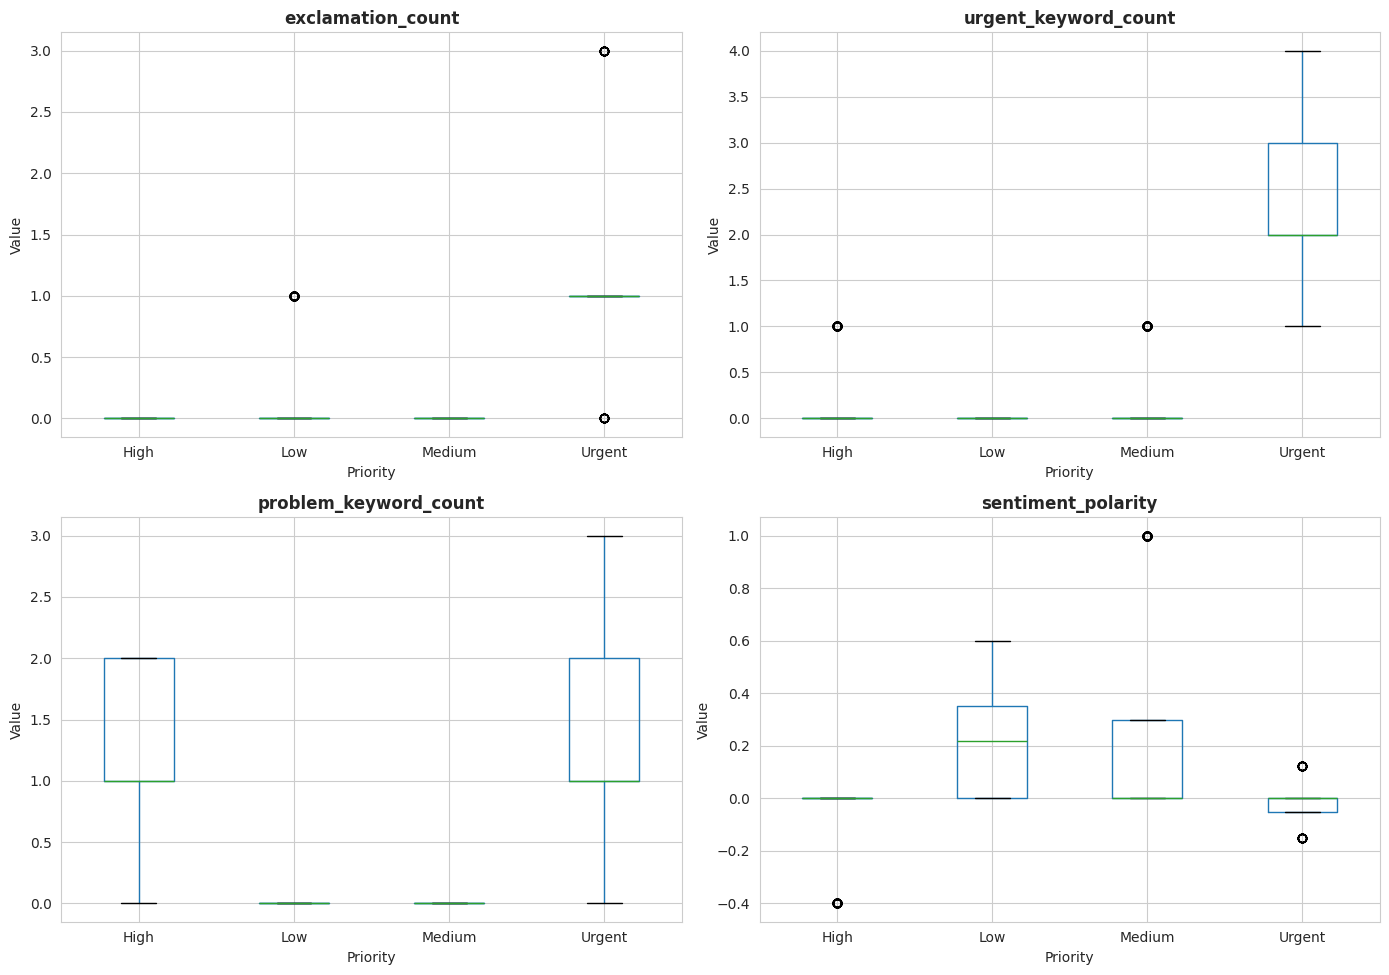


📊 VISUALIZATION INSIGHTS:
   • Exclamation marks: Higher in urgent emails
   • Urgent keywords: Clear difference between priorities
   • Sentiment: More negative in urgent/high priority


In [11]:
key_features = [
    'exclamation_count',
    'urgent_keyword_count',
    'problem_keyword_count',
    'sentiment_polarity'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    # Create DataFrame for plotting
    plot_df = pd.DataFrame({
        'Priority': df['priority'],
        'Value': custom_features[feature]
    })
    
    # Box plot
    plot_df.boxplot(column='Value', by='Priority', ax=axes[idx])
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Priority')
    axes[idx].set_ylabel('Value')
    axes[idx].get_figure().suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

print("\n📊 VISUALIZATION INSIGHTS:")
print("   • Exclamation marks: Higher in urgent emails")
print("   • Urgent keywords: Clear difference between priorities")
print("   • Sentiment: More negative in urgent/high priority")

## Combine All Features

In [12]:
print("Combining TF-IDF and custom features...")
print("-"*70)

# Convert custom features to sparse matrix for efficient combination
custom_features_sparse = csr_matrix(custom_features.values)

# Combine: [TF-IDF features | Custom features]
X = hstack([tfidf_features, custom_features_sparse])

# Target variable
y = df['priority']

print(f"✅ Combined feature matrix created!")
print(f"\nFinal feature matrix shape: {X.shape}")
print(f"   • TF-IDF features: {tfidf_features.shape[1]}")
print(f"   • Custom features: {custom_features.shape[1]}")
print(f"   • Total features: {X.shape[1]}")

print(f"\n🎯 Target variable (priority):")
print(y.value_counts())

Combining TF-IDF and custom features...
----------------------------------------------------------------------
✅ Combined feature matrix created!

Final feature matrix shape: (1000, 310)
   • TF-IDF features: 300
   • Custom features: 10
   • Total features: 310

🎯 Target variable (priority):
priority
Medium    400
High      250
Low       250
Urgent    100
Name: count, dtype: int64


## Train Test Split

In [13]:
print("Splitting data into train and test sets...")
print("="*70)

# Split with stratification (keeps class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,           # 20% for testing
    random_state=42,         # For reproducibility
    stratify=y               # Keep same class distribution in both sets
)

print(f"✅ Data split complete!")
print(f"\n📊 Training set:")
print(f"   • Samples: {X_train.shape[0]}")
print(f"   • Features: {X_train.shape[1]}")
print(f"   • Priority distribution:")
for priority, count in y_train.value_counts().items():
    percentage = count / len(y_train) * 100
    print(f"     - {priority:8s}: {count:3d} ({percentage:5.1f}%)")

print(f"\n📊 Test set:")
print(f"   • Samples: {X_test.shape[0]}")
print(f"   • Features: {X_test.shape[1]}")
print(f"   • Priority distribution:")
for priority, count in y_test.value_counts().items():
    percentage = count / len(y_test) * 100
    print(f"     - {priority:8s}: {count:3d} ({percentage:5.1f}%)")

print("\n💡 NOTE: Class distributions match! (thanks to stratify=y)")

Splitting data into train and test sets...
✅ Data split complete!

📊 Training set:
   • Samples: 800
   • Features: 310
   • Priority distribution:
     - Medium  : 320 ( 40.0%)
     - Low     : 200 ( 25.0%)
     - High    : 200 ( 25.0%)
     - Urgent  :  80 ( 10.0%)

📊 Test set:
   • Samples: 200
   • Features: 310
   • Priority distribution:
     - Medium  :  80 ( 40.0%)
     - High    :  50 ( 25.0%)
     - Low     :  50 ( 25.0%)
     - Urgent  :  20 ( 10.0%)

💡 NOTE: Class distributions match! (thanks to stratify=y)


## Create Feature Names List

In [14]:
all_feature_names = (
    list(tfidf_vectorizer.get_feature_names_out()) + 
    list(custom_features.columns)
)

print(f"Total features: {len(all_feature_names)}")
print(f"\n🔤 Sample TF-IDF features (first 10):")
print(all_feature_names[:10])

print(f"\n✨ Custom features (all):")
print(all_feature_names[-len(custom_features.columns):])

print("\n💡 Why we need feature names:")
print("   • To understand which features are most important")
print("   • To explain model predictions")
print("   • To debug if model isn't working well")

Total features: 310

🔤 Sample TF-IDF features (first 10):
['30', '30 minutes', '500', '500 integration', 'access', 'access account', 'access dashboard', 'access files', 'account', 'account hacked']

✨ Custom features (all):
['exclamation_count', 'question_count', 'caps_word_count', 'urgent_keyword_count', 'problem_keyword_count', 'sentiment_polarity', 'word_count', 'char_count', 'subject_length', 'subject_all_caps']

💡 Why we need feature names:
   • To understand which features are most important
   • To explain model predictions
   • To debug if model isn't working well


## Save Everything

In [15]:
import joblib
import json
from datetime import datetime

print("Saving feature engineering artifacts...")
print("-"*70)

# 1. Save the TF-IDF vectorizer (need this for new emails!)
joblib.dump(tfidf_vectorizer, '../models/tfidf_vectorizer.pkl')
print("✅ Saved TF-IDF vectorizer")

# 2. Save feature names
with open('../models/feature_names.json', 'w') as f:
    json.dump(all_feature_names, f, indent=2)
print("✅ Saved feature names")

# 3. Save train-test splits
joblib.dump({
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}, '../models/train_test_data.pkl')
print("✅ Saved train-test data")

# 4. Save metadata
metadata = {
    'created_date': datetime.now().isoformat(),
    'n_samples': len(df),
    'n_features': X.shape[1],
    'n_tfidf_features': tfidf_features.shape[1],
    'n_custom_features': custom_features.shape[1],
    'train_samples': X_train.shape[0],
    'test_samples': X_test.shape[0],
    'tfidf_params': {
        'max_features': 300,
        'min_df': 2,
        'max_df': 0.8,
        'ngram_range': '(1, 2)',
        'stop_words': 'english'
    },
    'custom_features': list(custom_features.columns)
}

with open('../models/feature_engineering_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✅ Saved metadata")

# 5. Save processed features DataFrame (optional, for analysis)
feature_df = pd.DataFrame(
    X.toarray(),
    columns=all_feature_names
)
feature_df['priority'] = y.values
feature_df.to_csv('../data/processed/features_complete.csv', index=False)
print("✅ Saved complete feature DataFrame")

print("\n" + "-"*70)
print("🎉 FEATURE ENGINEERING COMPLETE!")
print("-"*70)
print("\n📦 Saved files:")
print("   • models/tfidf_vectorizer.pkl")
print("   • models/feature_names.json")
print("   • models/train_test_data.pkl")
print("   • models/feature_engineering_metadata.json")
print("   • data/processed/features_complete.csv")

Saving feature engineering artifacts...
----------------------------------------------------------------------
✅ Saved TF-IDF vectorizer
✅ Saved feature names
✅ Saved train-test data
✅ Saved metadata
✅ Saved complete feature DataFrame

----------------------------------------------------------------------
🎉 FEATURE ENGINEERING COMPLETE!
----------------------------------------------------------------------

📦 Saved files:
   • models/tfidf_vectorizer.pkl
   • models/feature_names.json
   • models/train_test_data.pkl
   • models/feature_engineering_metadata.json
   • data/processed/features_complete.csv


## Summary and Next Steps

In [16]:
print("-"*70)
print("📋 FEATURE ENGINEERING SUMMARY")
print("-"*70)

print("\n✅ COMPLETED TASKS:")
print("   1. Loaded and cleaned email text")
print("   2. Created TF-IDF features (300 features)")
print("   3. Extracted custom urgency features (9 features)")
print("   4. Combined into single feature matrix (309 features)")
print("   5. Split into train (80%) and test (20%) sets")
print("   6. Saved all artifacts for model training")

print("\n📊 FEATURE BREAKDOWN:")
print(f"   • Total features: {X.shape[1]}")
print(f"   • TF-IDF (text content): {tfidf_features.shape[1]}")
print(f"   • Custom (urgency signals): {custom_features.shape[1]}")

print("\n🎯 KEY FEATURES IDENTIFIED:")
print("   TF-IDF captured:")
print("      • Urgent: 'urgent', 'asap', 'critical', 'locked'")
print("      • Low: 'suggestion', 'feature', 'would be nice'")
print("   ")
print("   Custom features captured:")
print("      • Exclamation marks (!!!)")
print("      • Urgent keywords count")
print("      • Problem keywords (cannot, error, broken)")
print("      • Sentiment polarity")

print("\n💡 WHY THIS MATTERS:")
print("   • ML models need numbers, not text")
print("   • TF-IDF captures word importance")
print("   • Custom features capture domain knowledge")
print("   • Combination gives model the best chance")

print("\n✨ NEXT STEPS:")
print("   1. ✅ Data exploration - COMPLETE (Notebook 1)")
print("   2. ✅ Feature engineering - COMPLETE (Notebook 2)")
print("   3. ⏭️  Model training - NEXT (Notebook 3)")
print("   4. ⏭️  Model evaluation")
print("   5. ⏭️  Build API")

print("\n" + "-"*70)
print("Ready to train your model! 🚀")
print("-"*70)

----------------------------------------------------------------------
📋 FEATURE ENGINEERING SUMMARY
----------------------------------------------------------------------

✅ COMPLETED TASKS:
   1. Loaded and cleaned email text
   2. Created TF-IDF features (300 features)
   3. Extracted custom urgency features (9 features)
   4. Combined into single feature matrix (309 features)
   5. Split into train (80%) and test (20%) sets
   6. Saved all artifacts for model training

📊 FEATURE BREAKDOWN:
   • Total features: 310
   • TF-IDF (text content): 300
   • Custom (urgency signals): 10

🎯 KEY FEATURES IDENTIFIED:
   TF-IDF captured:
      • Urgent: 'urgent', 'asap', 'critical', 'locked'
      • Low: 'suggestion', 'feature', 'would be nice'
   
   Custom features captured:
      • Exclamation marks (!!!)
      • Urgent keywords count
      • Problem keywords (cannot, error, broken)
      • Sentiment polarity

💡 WHY THIS MATTERS:
   • ML models need numbers, not text
   • TF-IDF captures wo

## Verify for these files

```text
models/
├── tfidf_vectorizer.pkl              ← TF-IDF transformer
├── feature_names.json                ← List of all features
├── train_test_data.pkl               ← Split data
└── feature_engineering_metadata.json ← Info about features

data/processed/
└── features_complete.csv             ← Full feature matrix
```